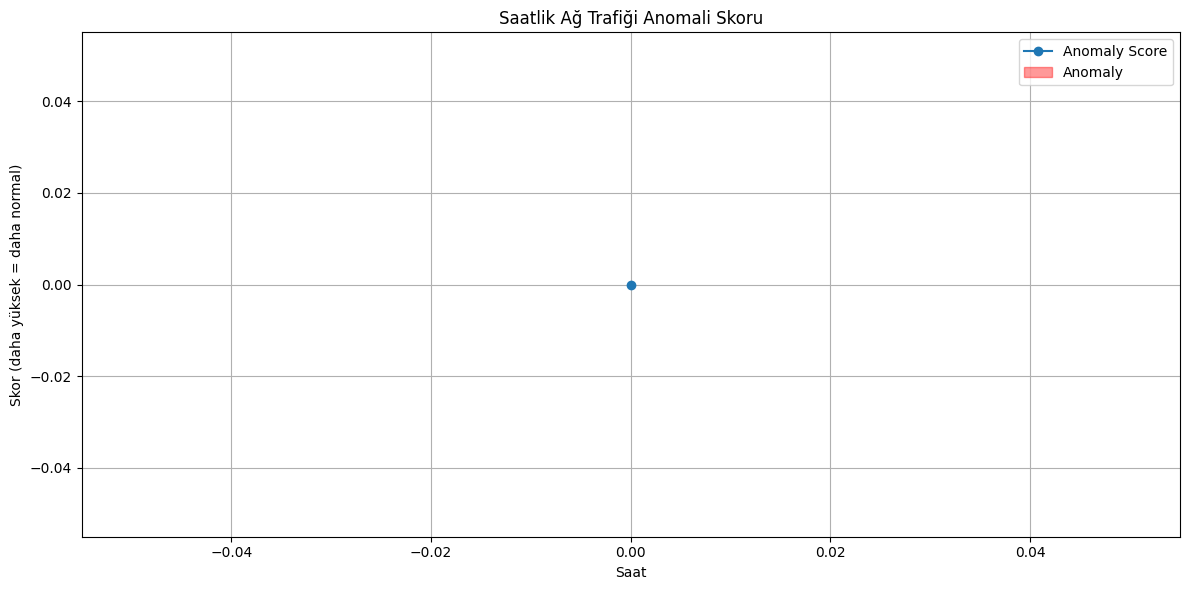

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import joblib

# 1. Veriyi oku
df = pd.read_json("traffic_log10.json", lines=True)

# 2. Özellik çıkarımı
df["hour"] = pd.to_datetime(df["timestamp"]).dt.hour
grouped = df.groupby("hour").agg({
    "packet_length": ["sum", "count"],
    "dst_ip": pd.Series.nunique,
    "dst_port": pd.Series.nunique
}).fillna(0)

grouped.columns = ["total_bytes", "packet_count", "unique_dst_ip", "unique_dst_port"]

# 3. Scaler ve modeli yükle
scaler = joblib.load("scaler.pkl")
model = joblib.load("anomaly_model.pkl")

# 4. Normalizasyon
X = scaler.transform(grouped)

# 5. Anomali skorlarını hesapla
scores = model.decision_function(X)  # Yüksek = daha normal
anomaly = model.predict(X)  # -1 = anormal, 1 = normal

# 6. Görselleştir
plt.figure(figsize=(12,6))
plt.plot(grouped.index, scores, label="Anomaly Score", marker="o")
plt.fill_between(grouped.index, scores, where=anomaly==-1, color="red", alpha=0.4, label="Anomaly")
plt.title("Saatlik Ağ Trafiği Anomali Skoru")
plt.xlabel("Saat")
plt.ylabel("Skor (daha yüksek = daha normal)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()